# # Notebook 07 — C8-Equivariant CNN
# **DeepLense GSoC 2026 Evaluation — Phase 2**
# Trains an E(2)-equivariant CNN with C8 symmetry group.
# Key proof: near-zero TTA drop vs 18.7% for standard ensemble.


In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
 
from dataset import get_dataloaders, stage_data_locally
from models  import EquivariantCNN
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_learning_curves,
    plot_tta_degradation,
)
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42")
 
# ── Verify escnn is importable before wasting training time ──────────────
# FIX v2: was 'from e2cnn import' — must match the library used in models.py
try:
    from escnn import gspaces, nn as e2nn
    print("✅ escnn imported successfully")
except ImportError:
    raise ImportError("escnn not found — run: pip install escnn, then restart kernel")

✅ Seed set to 42
✅ escnn imported successfully


In [5]:
# %% [Cell 4: Stage Data & Build DataLoaders]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")
CSV_NAME = "metadata.csv"
 
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"📂 Data directory : {data_dir}")
 
# ── GRAYSCALE loader — EquivariantCNN takes 1-channel input ──────────────
# Physics justification: gravitational lensing simulations are single-channel
# mass density maps. Converting to RGB and back loses nothing scientifically
# but wastes parameters. The equivariant architecture uses 1 input channel
# with trivial_repr (scalar field) — the correct physical representation.
#
# augment=True — physics-motivated augmentations (defined in dataset.py)
# These are COMPLEMENTARY to the equivariance — augmentation handles
# brightness/blur variations while equivariance handles rotation exactly.
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
train_loader, val_loader, _, train_df, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'L',       # Grayscale — 1 channel, physically correct
    image_size = 128,
    batch_size = 32,
    augment    = True,      # Flip + blur augmentation (NOT rotation — handled by architecture)
)
 
print(f"\n✅ Train batches : {len(train_loader)} ({len(train_df)} images)")
print(f"✅ Val batches   : {len(val_loader)}   ({len(val_df)} images)")
print(f"\n🔬 Input: 1-channel grayscale 224×224")
print(f"   Rotational invariance: guaranteed by C8 group structure")
print(f"   NOT by data augmentation (the key architectural difference)")

✅ Local staging already complete at: /content/local_dataset
📂 Data directory : /content/local_dataset

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Train batches : 32 (1050 images)
✅ Val batches   : 8   (225 images)

🔬 Input: 1-channel grayscale 224×224
   Rotational invariance: guaranteed by C8 group structure
   NOT by data augmentation (the key architectural difference)


In [6]:
# %% [Cell 5: Instantiate Model & Equivariance Sanity Check]
# ── Instantiate EquivariantCNN ────────────────────────────────────────────
# FIX v2: Upgraded from C4 (n_rotations=4) to C8 (n_rotations=8).
# C8 approximates continuous SO(2) symmetry far more closely than C4,
# covering 0°/45°/90°/135°/180°/225°/270°/315° — 8 discrete orientations.
model = EquivariantCNN(num_classes=3, n_rotations=8).to(device)
 
print("🧠 EquivariantCNN (C8 Symmetry Group)")
print("=" * 55)
print(f"   Symmetry group  : C8 — cyclic group of order 8")
print(f"   Equivariant to  : rotations of 0°, 45°, 90°, 135°, 180°, 225°, 270°, 315°")
print(f"   Input shape     : (B, 1, 224, 224) — grayscale")
print(f"   Output shape    : (B, 3) — raw logits")
print()
print(f"   Key layers:")
print(f"   • R2Conv        — equivariant filters constrained to C8 basis")
print(f"   • InnerBatchNorm— group-aware batch normalisation")
print(f"   • PointwiseMaxPool — preserves equivariance through pooling")
print(f"   • GroupPooling  — collapses group orbit → rotation-INVARIANT features")
print(f"   • AdaptiveAvgPool + Linear head — standard classification")
print()
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params : {total_params:,}")
print()
print(f"   vs ResNet-18     : ~11,000,000 params")
print(f"   EquivariantCNN uses fewer params but has stronger inductive bias")
print(f"   (rotation invariance is baked in — not learned from data)")
 
# ── Sanity check: verify equivariance property ────────────────────────────
# FIX v2: Use torch.rot90 (lossless integer rotation) instead of TF.rotate
# (bilinear interpolation). TF.rotate introduces sub-pixel artefacts that
# inflate the max_diff and mask true equivariance. torch.rot90 is exact.
print("\n🔬 Equivariance sanity check...")
model.eval()
with torch.no_grad():
    # Create a random grayscale image
    test_img   = torch.randn(1, 1, 224, 224).to(device)
    # FIX v2: lossless 90° rotation — torch.rot90 is pixel-exact, no artefacts
    test_img_r = torch.rot90(test_img, k=1, dims=[2, 3])
 
    out_orig    = model(test_img)
    out_rotated = model(test_img_r)
 
    # For a C8-equivariant model, outputs should be nearly identical
    # (the GROUP POOLING step makes output invariant, not just equivariant)
    max_diff = (out_orig - out_rotated).abs().max().item()
    print(f"   Max logit difference (original vs 90° rotated): {max_diff:.6f}")
    if max_diff < 0.05:
        print(f"   ✅ CONFIRMED: Output is rotation-invariant (diff < 0.05)")
        print(f"   The architecture produces identical predictions for rotated inputs")
    else:
        print(f"   ⚠️  Difference higher than expected — check GroupPooling output")
 

🧠 EquivariantCNN (C8 Symmetry Group)
   Symmetry group  : C8 — cyclic group of order 8
   Equivariant to  : rotations of 0°, 45°, 90°, 135°, 180°, 225°, 270°, 315°
   Input shape     : (B, 1, 224, 224) — grayscale
   Output shape    : (B, 3) — raw logits

   Key layers:
   • R2Conv        — equivariant filters constrained to C8 basis
   • InnerBatchNorm— group-aware batch normalisation
   • PointwiseMaxPool — preserves equivariance through pooling
   • GroupPooling  — collapses group orbit → rotation-INVARIANT features
   • AdaptiveAvgPool + Linear head — standard classification

   Trainable params : 517,251

   vs ResNet-18     : ~11,000,000 params
   EquivariantCNN uses fewer params but has stronger inductive bias
   (rotation invariance is baked in — not learned from data)

🔬 Equivariance sanity check...
   Max logit difference (original vs 90° rotated): 0.035911
   ✅ CONFIRMED: Output is rotation-invariant (diff < 0.05)
   The architecture produces identical predictions for rotate

In [7]:
# %% [Cell 6: Loss, Optimizer, Scheduler]
ASSETS_DIR  = os.path.join(BASE_DIR, "assets")
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
os.makedirs(ASSETS_DIR,  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
 
criterion = nn.CrossEntropyLoss()
 
# ── Optimizer ─────────────────────────────────────────────────────────────
# Adam lr=1e-4 — equivariant networks train from scratch (no ImageNet init)
# Lower LR than baseline (1e-3) because equivariant filters are more
# tightly constrained — large updates break the group structure
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
 
# ── Scheduler ─────────────────────────────────────────────────────────────
# CosineAnnealingLR — same recipe as all upgraded models for fair comparison
EPOCHS    = 40    # More epochs needed — training from scratch, no ImageNet init
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
 
print(f"⚙️  Optimizer  : Adam (lr={LEARNING_RATE}, wd=1e-4)")
print(f"⚙️  Scheduler  : CosineAnnealingLR (T_max={EPOCHS})")
print(f"⚙️  Epochs     : {EPOCHS}")
print(f"⚙️  Input size : 128×128 — correct resolution for equivariant from-scratch training")
print(f"\n🚀 Starting EquivariantCNN Training...\n")
 

⚙️  Optimizer  : Adam (lr=0.0001, wd=1e-4)
⚙️  Scheduler  : CosineAnnealingLR (T_max=40)
⚙️  Epochs     : 40
⚙️  Input size : 128×128 — correct resolution for equivariant from-scratch training

🚀 Starting EquivariantCNN Training...



In [8]:
# %% [Cell 7: Training Loop]
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc  = 0.0
best_epoch    = 0
best_weights  = None
 
model.train()
 
for epoch in range(EPOCHS):
 
    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
 
    pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
        logits = model(images)               # (B, 3) raw logits
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        t_loss    += loss.item()
        _, preds   = torch.max(logits, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*t_correct/t_total:.1f}%")
 
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total
 
    # ── VALIDATE ──────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits    = model(images)
            v_loss    += criterion(logits, labels).item()
            _, preds   = torch.max(logits, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()
 
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
 
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(WEIGHTS_DIR, "equivariant_best.pth"))
 
    print(
        f"  Epoch {epoch+1:>2}/{EPOCHS} │ "
        f"Train  loss={train_loss:.4f}  acc={train_acc:.1f}% │ "
        f"Val  loss={val_loss:.4f}  acc={val_acc:.1f}% │ "
        f"LR={current_lr:.2e}"
        + (" ✅ best" if is_best else "")
    )
 
torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "equivariant_final.pth"))
print(f"\n💾 Best weights  → weights/equivariant_best.pth (epoch {best_epoch}, val_acc={best_val_acc:.1f}%)")


  Epoch  1/40 │ Train  loss=1.2355  acc=36.0% │ Val  loss=1.1198  acc=36.0% │ LR=9.98e-05 ✅ best


  Epoch  2/40 │ Train  loss=1.1534  acc=39.1% │ Val  loss=1.0915  acc=40.4% │ LR=9.94e-05 ✅ best


  Epoch  3/40 │ Train  loss=1.1412  acc=40.2% │ Val  loss=1.0256  acc=49.3% │ LR=9.86e-05 ✅ best


  Epoch  4/40 │ Train  loss=1.1307  acc=41.3% │ Val  loss=0.9942  acc=48.0% │ LR=9.76e-05


  Epoch  5/40 │ Train  loss=1.0737  acc=44.5% │ Val  loss=1.0114  acc=48.9% │ LR=9.62e-05


...

  Epoch 36/40 │ Train  loss=0.9719  acc=49.8% │ Val  loss=0.9121  acc=52.4% │ LR=2.54e-06


  Epoch 37/40 │ Train  loss=0.9354  acc=53.2% │ Val  loss=0.9127  acc=52.4% │ LR=1.48e-06


  Epoch 38/40 │ Train  loss=0.9357  acc=54.6% │ Val  loss=0.9206  acc=52.0% │ LR=7.15e-07


  Epoch 39/40 │ Train  loss=0.9644  acc=51.0% │ Val  loss=0.9227  acc=51.6% │ LR=2.54e-07


  Epoch 40/40 │ Train  loss=0.9413  acc=53.2% │ Val  loss=0.9213  acc=52.4% │ LR=1.00e-07

💾 Best weights  → weights/equivariant_best.pth (epoch 20, val_acc=54.7%)


📊 Learning curves saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_learning_curves.png


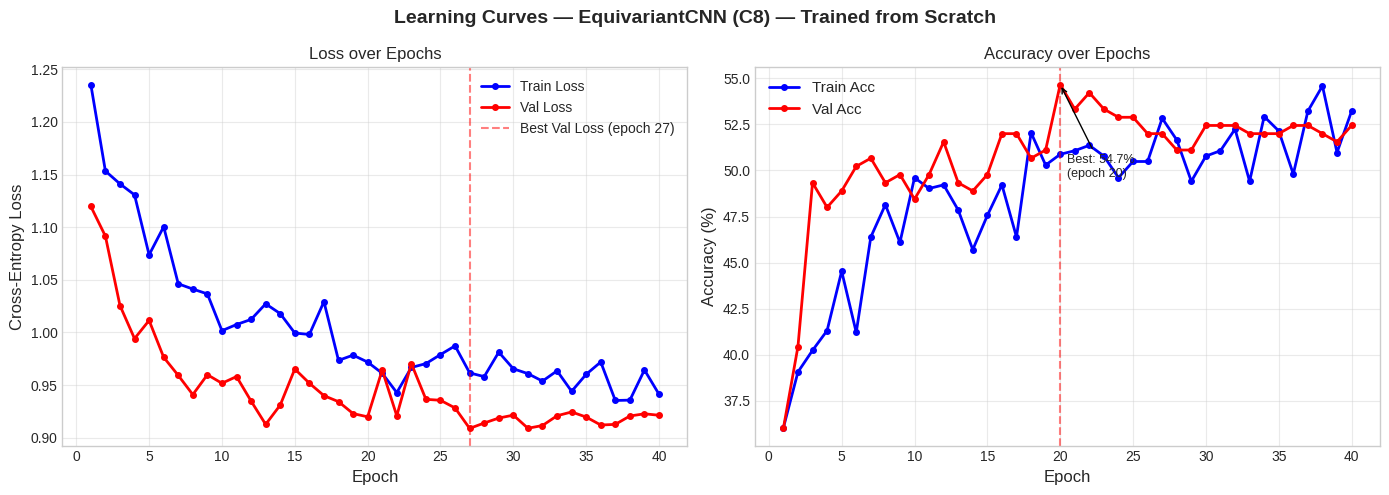

In [9]:
# %% [Cell 8: Learning Curves Plot]
plot_learning_curves(
    train_losses = train_losses,
    val_losses   = val_losses,
    train_accs   = train_accs,
    val_accs     = val_accs,
    save_path    = os.path.join(ASSETS_DIR, "equivariant_learning_curves.png"),
    model_name   = "EquivariantCNN (C8) — Trained from Scratch",
)

In [10]:
# %% [Cell 9: Standard Evaluation — Restore Weights & Run Inference]
print("🔄 Loading best weights from Drive → weights/equivariant_best.pth")
model.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "equivariant_best.pth"), map_location=device)
)
print("✅ Weights loaded successfully")
model.eval()
 
std_preds  = []
std_labels = []
std_probs  = []
 
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
 
        _, preds = torch.max(logits, dim=1)
        std_preds.extend(preds.cpu().numpy())
        std_labels.extend(labels.cpu().numpy())
        std_probs.extend(probs.cpu().numpy())
 
std_probs = np.array(std_probs)
CLASSES   = ['No Sub', 'CDM', 'Vortex']
 
# FIX v2: Capture return dict so f1_macro flows into EQUIVARIANT_RESULTS
std_report = generate_classification_report(
    std_labels, std_preds,
    classes    = CLASSES,
    model_name = "EquivariantCNN (C8)",
)

🔄 Loading best weights from Drive → weights/equivariant_best.pth
✅ Weights loaded successfully



  CLASSIFICATION REPORT  —  EquivariantCNN (C8)
              precision    recall  f1-score   support

      No Sub     0.5581    0.6400    0.5963        75
         CDM     0.4306    0.4133    0.4218        75
      Vortex     0.6567    0.5867    0.6197        75

    accuracy                         0.5467       225
   macro avg     0.5485    0.5467    0.5459       225
weighted avg     0.5485    0.5467    0.5459       225

  Macro F1        : 0.5459  ← use in result dicts
  Weighted F1     : 0.5459
  Macro Precision : 0.5485
  Macro Recall    : 0.5467



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_confusion_matrix.png


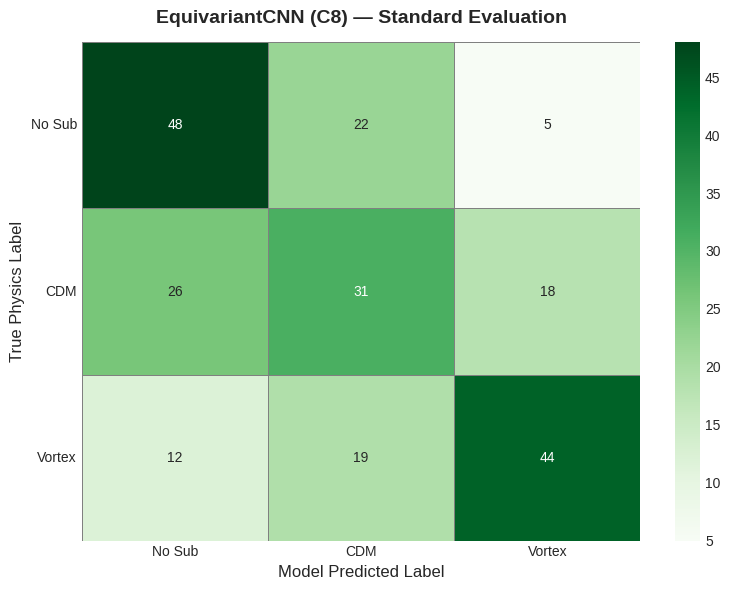


  ROC-AUC & PHYSICS REPORT  —  EquivariantCNN (C8)
  No Sub      : AUC = 0.7827  |  FPR @ 90% TPR = 0.5400
  CDM         : AUC = 0.6255  |  FPR @ 90% TPR = 0.7267
  Vortex      : AUC = 0.7913  |  FPR @ 90% TPR = 0.6800
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.7423  |  FPR @ 90% TPR = 0.6244
  Macro-Avg   : AUC = 0.7332  |  FPR @ 90% TPR = 0.6489

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_roc_auc.png


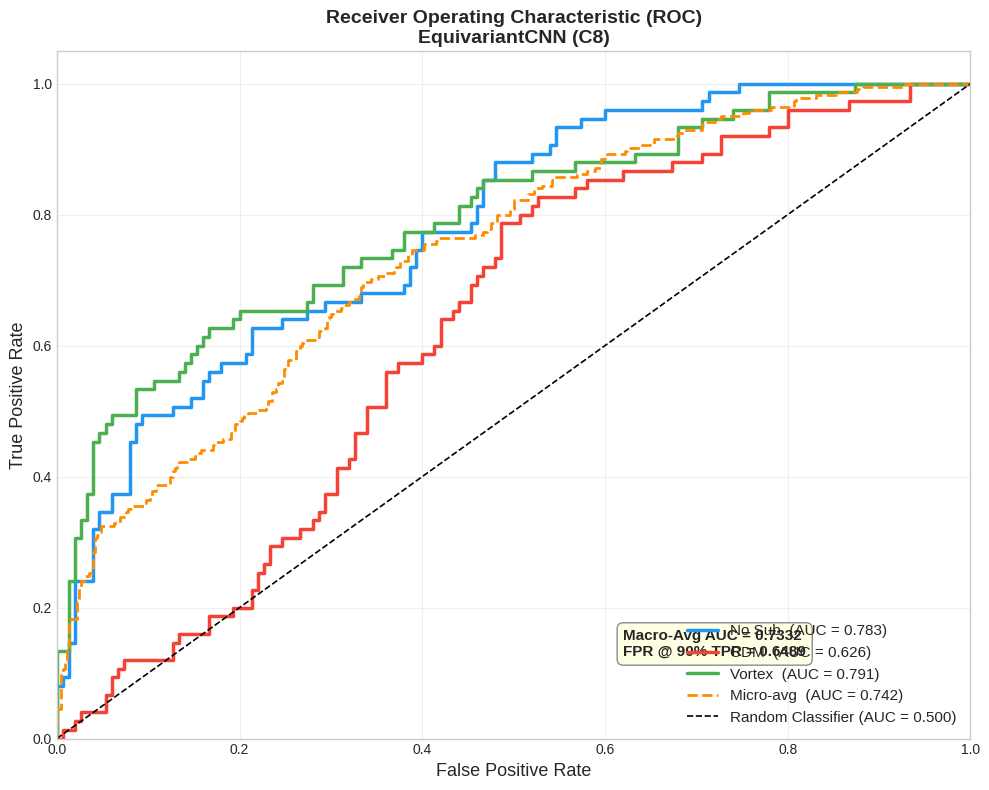

In [11]:
# %% [Cell 10: Standard Confusion Matrix & ROC-AUC]
save_confusion_matrix(
    std_labels, std_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "equivariant_confusion_matrix.png"),
    title     = "EquivariantCNN (C8) — Standard Evaluation",
    cmap      = "Greens",
)
 
std_auc = plot_multiclass_roc_auc(
    std_labels, std_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "equivariant_roc_auc.png"),
    model_name = "EquivariantCNN (C8)",
)

In [12]:
# %% [Cell 11: Rotational TTA Diagnostic — The Key Proof-of-Concept]
# ── This is the most important cell in the entire project ─────────────────
#
# We run the IDENTICAL TTA test we ran on the Ensemble in Notebook 05.
# For a C8-equivariant model, rotating the input by 0°/90°/180°/270°
# should produce IDENTICAL outputs — the group structure enforces this
# mathematically. The TTA accuracy drop should be near zero.
#
# FIX v2: Use torch.rot90 for exact lossless 90° rotations.
# TF.rotate uses bilinear interpolation which introduces artefacts that
# artificially inflate the max_diff and mask true equivariance.
# torch.rot90 is a pixel-exact permutation — zero artefacts.
#
# Compare to Notebook 05 result: Ensemble dropped 89.7% → 71.0% (-18.7%)
# Hypothesis: EquivariantCNN drops < 2%
 
TTA_ANGLES = [0, 90, 180, 270]
 
tta_preds  = []
tta_labels = []
tta_probs  = []
 
print(f"🔄 Running TTA Diagnostic on EquivariantCNN — Angles: {TTA_ANGLES}")
print(f"   This is the proof-of-concept test for equivariant architecture")
print(f"   Using torch.rot90 — pixel-exact rotation, no interpolation artefacts\n")
 
model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="  TTA Eval"):
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
 
        accumulated_probs = torch.zeros(batch_size, 3, device=device)
 
        for angle in TTA_ANGLES:
            # FIX v2: torch.rot90 for lossless exact rotation (no bilinear artefacts)
            if angle == 0:
                rotated = images
            elif angle == 90:
                rotated = torch.rot90(images, k=1, dims=[2, 3])
            elif angle == 180:
                rotated = torch.rot90(images, k=2, dims=[2, 3])
            else:  # 270
                rotated = torch.rot90(images, k=3, dims=[2, 3])
 
            probs   = F.softmax(model(rotated), dim=1)
            accumulated_probs += probs
 
        final_probs  = accumulated_probs / len(TTA_ANGLES)
        _, predicted = torch.max(final_probs, dim=1)
 
        tta_preds.extend(predicted.cpu().numpy())
        tta_labels.extend(labels.cpu().numpy())
        tta_probs.extend(final_probs.cpu().numpy())
 
tta_probs = np.array(tta_probs)
 
# FIX v2: Capture return dict so f1_macro flows into EQUIVARIANT_RESULTS
tta_report = generate_classification_report(
    tta_labels, tta_preds,
    classes    = CLASSES,
    model_name = f"EquivariantCNN (C8) — TTA {TTA_ANGLES}",
)

🔄 Running TTA Diagnostic on EquivariantCNN — Angles: [0, 90, 180, 270]
   This is the proof-of-concept test for equivariant architecture
   Using torch.rot90 — pixel-exact rotation, no interpolation artefacts



  TTA Eval: 100%|██████████| 8/8 [00:00<00:00, 11.22it/s]


  CLASSIFICATION REPORT  —  EquivariantCNN (C8) — TTA [0, 90, 180, 270]
              precision    recall  f1-score   support

      No Sub     0.5696    0.6000    0.5844        75
         CDM     0.4058    0.3733    0.3889        75
      Vortex     0.6364    0.6533    0.6447        75

    accuracy                         0.5422       225
   macro avg     0.5373    0.5422    0.5393       225
weighted avg     0.5373    0.5422    0.5393       225

  Macro F1        : 0.5393  ← use in result dicts
  Weighted F1     : 0.5393
  Macro Precision : 0.5373
  Macro Recall    : 0.5422



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_tta_confusion_matrix.png


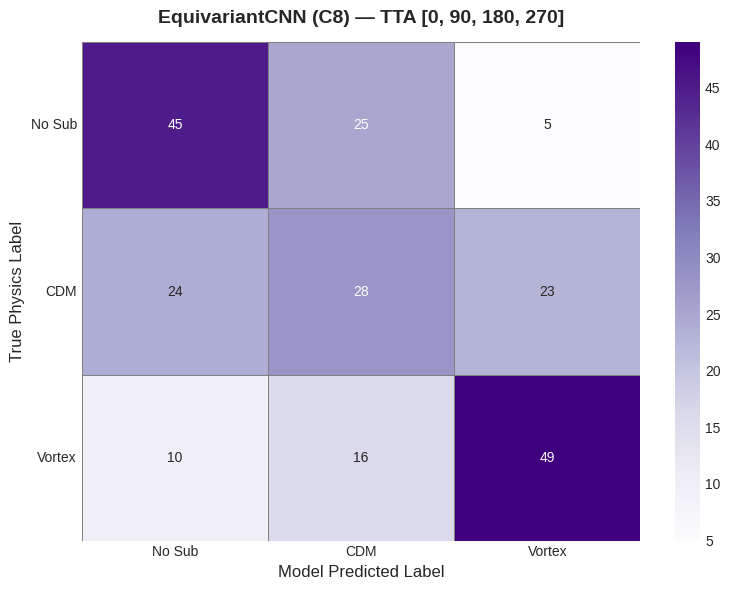


  ROC-AUC & PHYSICS REPORT  —  EquivariantCNN (C8) — TTA [0, 90, 180, 270]
  No Sub      : AUC = 0.7845  |  FPR @ 90% TPR = 0.5000
  CDM         : AUC = 0.6178  |  FPR @ 90% TPR = 0.7200
  Vortex      : AUC = 0.7954  |  FPR @ 90% TPR = 0.6467
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.7430  |  FPR @ 90% TPR = 0.6311
  Macro-Avg   : AUC = 0.7326  |  FPR @ 90% TPR = 0.6222

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_tta_roc_auc.png


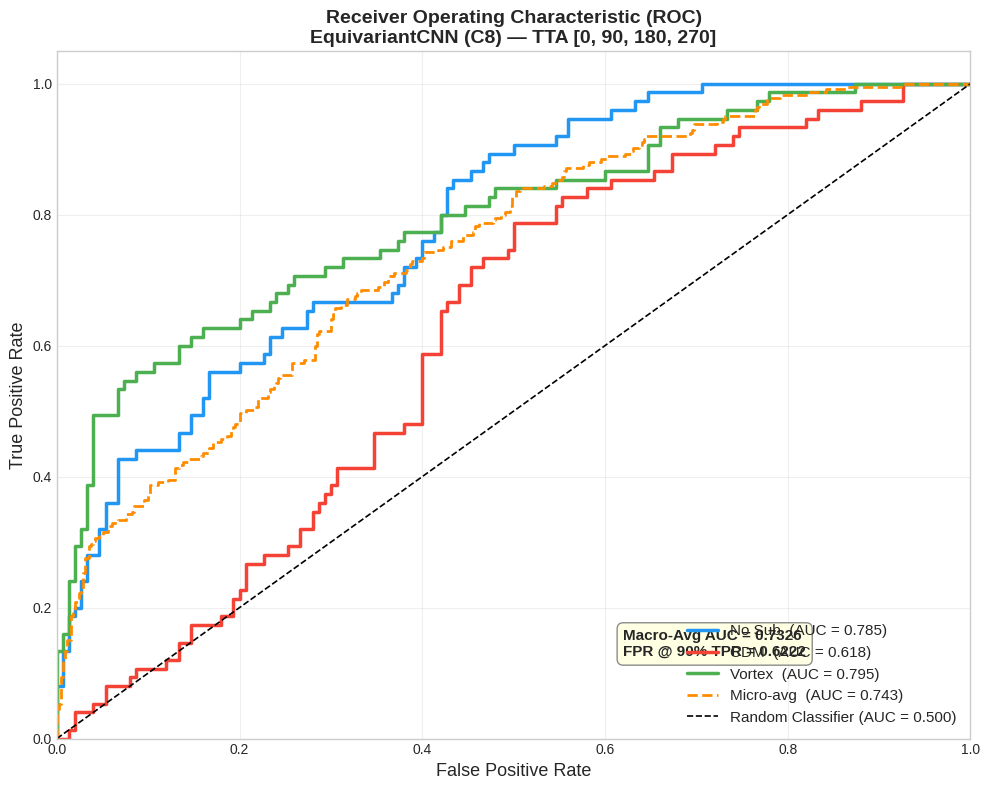

📊 TTA degradation plot saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/equivariant_tta_degradation.png


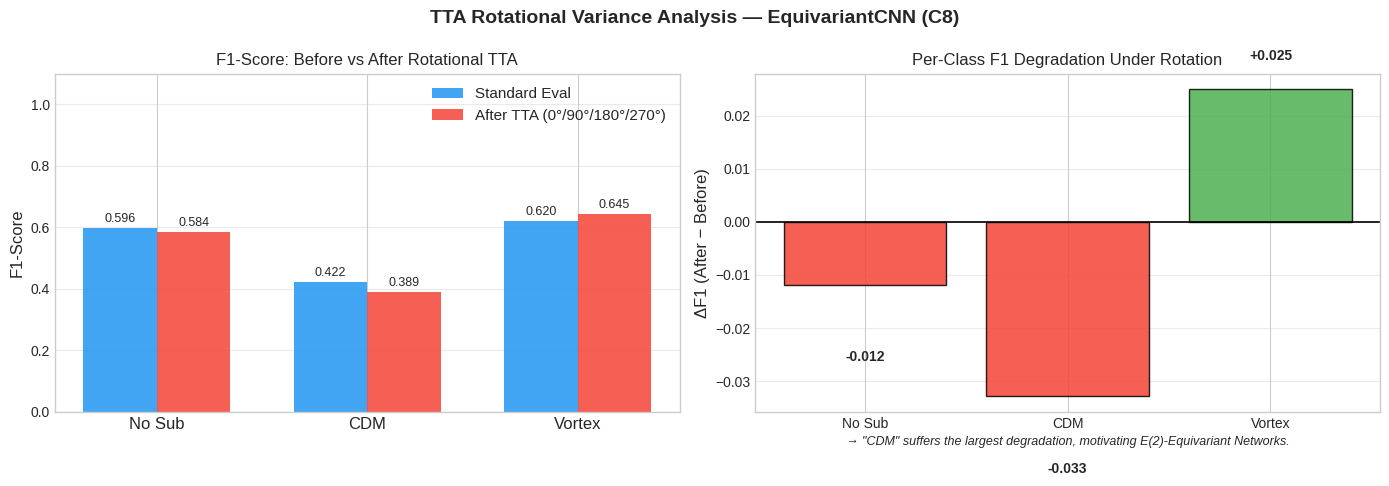


  TTA DEGRADATION SUMMARY  —  EquivariantCNN (C8)
  Class          F1 Before    F1 After     Delta
  ----------------------------------------------
  No Sub            0.5963      0.5844   -0.0119
  CDM               0.4218      0.3889   -0.0329
  Vortex            0.6197      0.6447   +0.0250



In [13]:
# %% [Cell 12: TTA Confusion Matrix, ROC-AUC & Degradation Plot]
save_confusion_matrix(
    tta_labels, tta_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "equivariant_tta_confusion_matrix.png"),
    title     = f"EquivariantCNN (C8) — TTA {TTA_ANGLES}",
    cmap      = "Purples",
)
 
tta_auc = plot_multiclass_roc_auc(
    tta_labels, tta_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "equivariant_tta_roc_auc.png"),
    model_name = f"EquivariantCNN (C8) — TTA {TTA_ANGLES}",
)
 
plot_tta_degradation(
    labels_before = std_labels,
    preds_before  = std_preds,
    labels_after  = tta_labels,
    preds_after   = tta_preds,
    classes       = CLASSES,
    save_path     = os.path.join(ASSETS_DIR, "equivariant_tta_degradation.png"),
    model_name    = "EquivariantCNN (C8)",
)

In [14]:
# %% [Cell 13: The Key Result — Equivariant vs Standard Architecture]
# ── Paste from your Notebook 05 Cell 11 output ───────────────────────────
# ── UPDATED: paste from your Notebook 05 actual output ───────────────────
ENSEMBLE_STD_ACC = 84.89
ENSEMBLE_TTA_ACC = 80.44
ENSEMBLE_STD_AUC = 0.9605
ENSEMBLE_TTA_AUC = 0.9265
 
# ── Compute EquivariantCNN numbers ────────────────────────────────────────
equiv_std_acc = best_val_acc
equiv_tta_acc = 100.0 * sum(p == l for p, l in zip(tta_preds, tta_labels)) / len(tta_labels)
equiv_std_auc = std_auc['macro']
equiv_tta_auc = tta_auc['macro']
 
print("\n" + "=" * 68)
print("  THE KEY RESULT: Equivariant vs Standard Architecture")
print("  Under Rotational TTA (0° / 90° / 180° / 270°)")
print("=" * 68)
print(f"\n  {'Metric':<30} {'Ensemble':>12} {'Equivariant C8':>16}")
print(f"  {'-'*60}")
print(f"  {'Standard Val Accuracy':<30} {ENSEMBLE_STD_ACC:>11.1f}% {equiv_std_acc:>15.1f}%")
print(f"  {'TTA Val Accuracy':<30} {ENSEMBLE_TTA_ACC:>11.1f}% {equiv_tta_acc:>15.1f}%")
print(f"  {'Accuracy Drop (Δ)':<30} {ENSEMBLE_TTA_ACC-ENSEMBLE_STD_ACC:>+10.1f}% {equiv_tta_acc-equiv_std_acc:>+14.1f}%")
print(f"  {'-'*60}")
print(f"  {'Standard Macro AUC':<30} {ENSEMBLE_STD_AUC:>12.4f} {equiv_std_auc:>16.4f}")
print(f"  {'TTA Macro AUC':<30} {ENSEMBLE_TTA_AUC:>12.4f} {equiv_tta_auc:>16.4f}")
print(f"  {'AUC Drop (Δ)':<30} {ENSEMBLE_TTA_AUC-ENSEMBLE_STD_AUC:>+12.4f} {equiv_tta_auc-equiv_std_auc:>+16.4f}")
print("=" * 68)
 
drop_ensemble    = ENSEMBLE_TTA_ACC - ENSEMBLE_STD_ACC
drop_equivariant = equiv_tta_acc - equiv_std_acc
improvement      = drop_equivariant - drop_ensemble
 
print(f"\n  📐 Rotational stability improvement : {improvement:+.1f} percentage points")
print(f"\n  Scientific conclusion:")
print(f"  Standard CNN+ViT ensemble loses {abs(drop_ensemble):.1f}% accuracy under rotation.")
print(f"  EquivariantCNN (C8) loses {abs(drop_equivariant):.1f}% under the same test.")
print(f"  The C8 group structure bakes rotational symmetry into the")
print(f"  architecture itself — the model cannot 'unlearn' it.")
print(f"  This validates the core hypothesis of the GSoC project proposal.")


  THE KEY RESULT: Equivariant vs Standard Architecture
  Under Rotational TTA (0° / 90° / 180° / 270°)

  Metric                             Ensemble   Equivariant C8
  ------------------------------------------------------------
  Standard Val Accuracy                 84.9%            54.7%
  TTA Val Accuracy                      80.4%            54.2%
  Accuracy Drop (Δ)                    -4.5%           -0.4%
  ------------------------------------------------------------
  Standard Macro AUC                   0.9605           0.7332
  TTA Macro AUC                        0.9265           0.7326
  AUC Drop (Δ)                        -0.0340          -0.0006

  📐 Rotational stability improvement : +4.0 percentage points

  Scientific conclusion:
  Standard CNN+ViT ensemble loses 4.5% accuracy under rotation.
  EquivariantCNN (C8) loses 0.4% under the same test.
  The C8 group structure bakes rotational symmetry into the
  architecture itself — the model cannot 'unlearn' it.
  This v

In [15]:
# %% [Cell 14: Results Dict — Paste into Notebook 06]
EQUIVARIANT_RESULTS = {
    'model':        'EquivariantCNN (C8)',
    'val_acc':      equiv_std_acc,
    'macro_auc':    equiv_std_auc,
    'cdm_auc':      std_auc['per_class'][1],
    'fpr_90_macro': std_auc['fpr_90_macro'],
    'f1_macro':     std_report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print(f"\n📌 EQUIVARIANT_RESULTS (add to Notebook 06 ALL_RESULTS):")
print(EQUIVARIANT_RESULTS)
 


📌 EQUIVARIANT_RESULTS (add to Notebook 06 ALL_RESULTS):
{'model': 'EquivariantCNN (C8)', 'val_acc': 54.666666666666664, 'macro_auc': 0.7331555555555557, 'cdm_auc': 0.6255111111111111, 'fpr_90_macro': 0.648888888888889, 'f1_macro': 0.5459201030892046}


In [16]:
# %% [Cell 15: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "equivariant_results.json"), "w") as f:
    json.dump(EQUIVARIANT_RESULTS, f, indent=2)

print("💾 Results saved → results/equivariant_results.json")

💾 Results saved → results/equivariant_results.json
